# Writer Identify Pytorch Lightning CNN

https://www.kaggle.com/code/stpeteishii/embryo-quality-pytorch-lightning-cnn

This dataset is used for writer identification purposes.

In [1]:
import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split
from torch.utils.data import DataLoader, Dataset, Subset
from torch.utils.data import random_split, SubsetRandomSampler
from torchvision import datasets, transforms, models 
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid
from pytorch_lightning import LightningModule
from pytorch_lightning import Trainer
import pytorch_lightning as pl
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from PIL import Image

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
dir0='/kaggle/input/bi-scriptual-writer-identification-dataset/ALL_DATA/ALL_DATA'

In [3]:
classes=[]
paths=[]
for dirname, _, filenames in os.walk(dir0):
    for filename in filenames:
        if filename.endswith('.png'):
            classes+=[dirname.split('/')[-1]]
            paths+=[(os.path.join(dirname, filename))]
print(len(paths))

5476


In [4]:
N=list(range(len(classes)))
class_names=sorted(set(classes))
print(class_names)
normal_mapping=dict(zip(class_names,N)) 
reverse_mapping=dict(zip(N,class_names))       

data=pd.DataFrame(columns=['path','class','label'])
data['path']=paths
data['class']=classes
data['label']=data['class'].map(normal_mapping)
m=len(data)
M=list(range(m))
random.shuffle(M)
data=data.iloc[M]

['1804001', '1804003', '1804005', '1804007', '1804008', '1804012', '1804013', '1804014', '1804015', '1804017', '1804018', '1804020', '1804021', '1804024', '1804025', '1804026', '1804027', '1804029', '1804031', '1804038', '1804040', '1804041', '1804043', '1804045']


In [5]:
transform=transforms.Compose([
        transforms.RandomRotation(10),      # rotate +/- 10 degrees
        transforms.RandomHorizontalFlip(),  # reverse 50% of images
        transforms.Resize(224),             # resize shortest side to 224 pixels
        transforms.CenterCrop(224),         # crop longest side to 224 pixels at center
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
])

In [6]:
def create_path_label_list(df):
    path_label_list = []
    for _, row in df.iterrows():
        path = row['path']
        label = row['label']
        path_label_list.append((path, label))
    return path_label_list

path_label = create_path_label_list(data)
path_label = random.sample(path_label,len(path_label))
print(len(path_label))
print(path_label[0:3])

5476
[('/kaggle/input/bi-scriptual-writer-identification-dataset/ALL_DATA/ALL_DATA/1804021/B_1804021 (42).png', 12), ('/kaggle/input/bi-scriptual-writer-identification-dataset/ALL_DATA/ALL_DATA/1804021/B_1804021 (8).png', 12), ('/kaggle/input/bi-scriptual-writer-identification-dataset/ALL_DATA/ALL_DATA/1804014/B_1804014 (16).png', 7)]


In [7]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, path_label, transform=None):
        self.path_label = path_label
        self.transform = transform

    def __len__(self):
        return len(self.path_label)

    def __getitem__(self, idx):
        path, label = self.path_label[idx]
        img = Image.open(path).convert('RGB')

        if self.transform is not None:
            img = self.transform(img)

        return img, label

In [8]:
class ImageDataset(pl.LightningDataModule):
    def __init__(self, path_label, batch_size=32):
        super().__init__()
        self.path_label = path_label
        self.batch_size = batch_size
        self.transform = transforms.Compose([
            transforms.Resize(224),             # resize shortest side to 224 pixels
            transforms.CenterCrop(224),         # crop longest side to 224 pixels at center            
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ])

    def setup(self, stage=None):
        dataset = CustomDataset(self.path_label, self.transform)
        dataset_size = len(dataset)
        train_size = int(0.8 * dataset_size) 
        val_size = dataset_size - train_size
        print(train_size,val_size)

        self.train_dataset = torch.utils.data.Subset(dataset, range(train_size))
        self.val_dataset = torch.utils.data.Subset(dataset, range(train_size, dataset_size))

    def __len__(self):
        if self.train_dataset is not None:
            return len(self.train_dataset)
        elif self.val_dataset is not None:
            return len(self.val_dataset)
        else:
            return 0        

    def __getitem__(self, index):
        if self.train_dataset is not None:
            return self.train_dataset[index]
        elif self.test_dataset is not None:
            return self.test_dataset[index]
        else:
            raise IndexError("Index out of range. The dataset is empty.")

    def train_dataset(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataset(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size)


In [9]:
class DataModule(pl.LightningDataModule):
    
    def __init__(self, transform=transform, batch_size=16):
        super().__init__()
        self.root_dir = dir0
        self.transform = transform
        self.batch_size = batch_size

    def setup(self, stage=None):
        data_set = datasets.ImageFolder(root=self.root_dir, transform=self.transform)
        
        n_data = len(dataset)
        n_train = int(0.8 * n_data)
        n_val = n_data - n_train
        train_dataset, val_dataset =  random_split(dataset, [n_train, n_val])

        self.train_dataset = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        self.val_dataset = DataLoader(val_dataset, batch_size=self.batch_size)
    
    def train_dataloader(self):
        return self.train_dataset

    def val_dataloader(self):
        return self.val_dataset
    
    def test_dataloader(self):
        return self.test_dataset

In [10]:
class ConvolutionalNetwork(LightningModule):
    
    def __init__(self):
        super(ConvolutionalNetwork, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 3, 1)
        self.conv2 = nn.Conv2d(6, 16, 3, 1)
        self.fc1 = nn.Linear(16 * 54 * 54, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 20)
        self.fc4 = nn.Linear(20, len(class_names))

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)
        X = X.view(-1, 16 * 54 * 54)
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = F.relu(self.fc3(X))
        X = self.fc4(X)
        return F.log_softmax(X, dim=1)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.001)
        return optimizer

    def training_step(self, train_batch, batch_idx):
        X, y = train_batch
        y_hat = self(X)
        loss = F.cross_entropy(y_hat, y)
        pred = y_hat.argmax(dim=1, keepdim=True)
        acc = pred.eq(y.view_as(pred)).sum().item() / y.shape[0]
        self.log("train_loss", loss)
        self.log("train_acc", acc)
        return loss

    def validation_step(self, val_batch, batch_idx):
        X, y = val_batch
        y_hat = self(X)
        loss = F.cross_entropy(y_hat, y)
        pred = y_hat.argmax(dim=1, keepdim=True)
        acc = pred.eq(y.view_as(pred)).sum().item() / y.shape[0]
        self.log("val_loss", loss)
        self.log("val_acc", acc)

    def test_step(self, test_batch, batch_idx):
        X, y = test_batch
        y_hat = self(X)
        loss = F.cross_entropy(y_hat, y)
        pred = y_hat.argmax(dim=1, keepdim=True)
        acc = pred.eq(y.view_as(pred)).sum().item() / y.shape[0]
        self.log("test_loss", loss)
        self.log("test_acc", acc)

In [11]:
dataset = ImageDataset(path_label)
dataset.setup() 
train_dataloader = dataset.train_dataloader
val_dataloader = dataset.val_dataloader
#test_dataloader = dataset.test_dataloader
datamodule = DataModule()
model = ConvolutionalNetwork()

4380 1096


In [12]:
trainer = pl.Trainer(max_epochs=100)
trainer.fit(model, datamodule)
val_loader = datamodule.val_dataloader()
trainer.test(dataloaders=val_loader)

Sanity Checking: 0it [00:00, ?it/s]

/opt/conda/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:442: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 4 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/opt/conda/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:442: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 4 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

/opt/conda/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/checkpoint_connector.py:149: UserWarning: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.
  rank_zero_warn(
/opt/conda/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:442: PossibleUserWarning: The dataloader, test_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 4 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Testing: 0it [00:00, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.23630136251449585    │
│         test_loss         │     8.639627456665039     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 8.639627456665039, 'test_acc': 0.23630136251449585}]

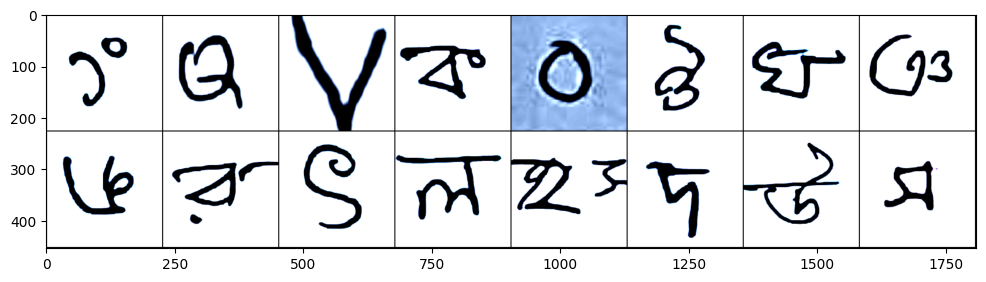

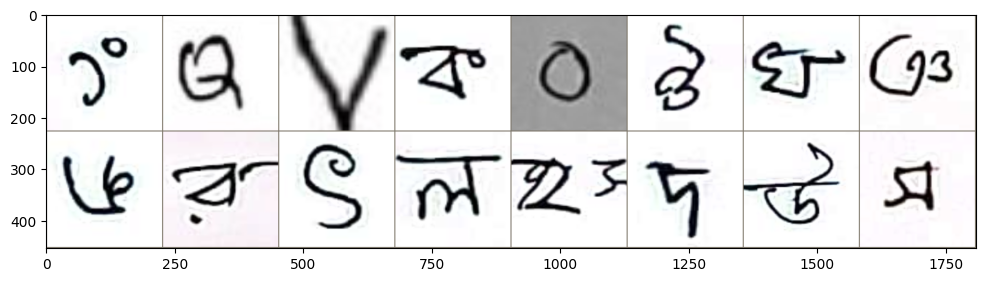

In [13]:
for images, labels in datamodule.val_dataloader():
    break
im=make_grid(images,nrow=8)

plt.figure(figsize=(12,12))
plt.imshow(np.transpose(im.numpy(),(1,2,0)))

inv_normalize=transforms.Normalize(mean=[-0.485/0.229,-0.456/0.224,-0.406/0.225],
                                   std=[1/0.229,1/0.224,1/0.225])
im=inv_normalize(im)

plt.figure(figsize=(12,12))
plt.imshow(np.transpose(im.numpy(),(1,2,0)))

In [14]:
device = torch.device("cpu")   #"cuda:0"

model.eval()
y_true=[]
y_pred=[]
with torch.no_grad():
    for test_data in datamodule.val_dataloader():
        test_images, test_labels = test_data[0].to(device), test_data[1].to(device)
        pred = model(test_images).argmax(dim=1)
        for i in range(len(pred)):
            y_true.append(test_labels[i].item())
            y_pred.append(pred[i].item())

print(classification_report(y_true,y_pred,target_names=class_names,digits=4))

              precision    recall  f1-score   support

     1804001     0.9677    0.9091    0.9375        33
     1804003     0.7500    0.4500    0.5625        40
     1804005     0.6557    0.9091    0.7619        44
     1804007     0.9412    0.8649    0.9014        37
     1804008     0.8667    0.7647    0.8125        34
     1804012     0.8750    0.8936    0.8842        47
     1804013     0.8485    0.9032    0.8750        31
     1804014     0.9500    0.9268    0.9383        41
     1804015     0.7273    0.8571    0.7869        28
     1804017     0.9677    0.8824    0.9231        34
     1804018     0.8043    0.9024    0.8506        41
     1804020     0.8936    0.9545    0.9231        44
     1804021     0.8125    0.8387    0.8254        31
     1804024     0.8684    0.8250    0.8462        40
     1804025     0.8462    0.8684    0.8571        38
     1804026     0.8276    0.8000    0.8136        30
     1804027     0.9143    0.8649    0.8889        37
     1804029     0.7647    

# Professional GUI for Writer Identification

This interface allows you to:
- Upload handwriting images easily
- Get instant writer predictions
- View confidence scores
- Use a clean modern interface with Gradio


In [ ]:

# =========================
# Professional GUI Interface
# =========================

!pip -q install gradio

import gradio as gr
from PIL import Image
import torch
import torchvision.transforms as transforms
import numpy as np

# Put model on correct device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# Prediction transform
gui_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# Prediction Function
def predict_writer(image):
    try:
        image = image.convert("RGB")

        img_tensor = gui_transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(img_tensor)
            probs = torch.softmax(outputs, dim=1)

            confidence, predicted = torch.max(probs, 1)

        predicted_class = reverse_mapping[predicted.item()]
        confidence_score = float(confidence.item()) * 100

        result = f"""
        Predicted Writer: {predicted_class}

        Confidence: {confidence_score:.2f}%
        """

        return result

    except Exception as e:
        return f"Error: {str(e)}"

# Custom Theme
custom_css = """
body {
    background-color: #0f172a;
}

.gradio-container {
    font-family: Arial, sans-serif;
}

h1 {
    text-align: center;
    color: white;
}

.output-text textarea {
    font-size: 18px !important;
    color: #22c55e !important;
}
"""

# Gradio Interface
demo = gr.Interface(
    fn=predict_writer,
    inputs=gr.Image(type="pil", label="Upload Handwriting Image"),
    outputs=gr.Textbox(label="Prediction Result"),
    title="Writer Identification System",
    description="""
    Upload a handwriting image and the CNN model will identify the writer.
    """,
    theme=gr.themes.Soft(),
    css=custom_css,
    allow_flagging="never"
)

demo.launch(debug=True)
